# Aberrated Image Recovery of Ultracold Atoms

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd
import scipy as sp
import skimage as ski
import sklearn as skl
from sklearn import cluster

## Overview

<div>
<img src="https://raw.githubusercontent.com/illinois-ipaml/MachineLearningForPhysics/main/img/Project_UltraColdAtoms.png" width=600></img>
</div>

## <span style="color:Orange">Overview</span>
Over the past 20-30 years the groundwork has been laid for precise experimental control of atomic gases at ultracold temperatures. These ultracold atom gas experiments explore the quantum mechanics of their underlying atomic systems to a diverse set applications ranging from the simulation of computationally difficult physics problems [1] to the sensing of new physics beyond the standard model [2]. Most experiments in this field rely on directly imaging the ultracold gas they make, in order to extract data about the size and shape of the atomic number density distribution being imaged.

The goal of this project is to introduce you to some relevant image processing techniques, as well as to get familiar with an image as a data element. As you will demonstrate, images are a kind of data with a very large number of features, but where almost all of those features within some region of interest are highly correlated. Of interest in this project is how the effects of real imaging systems distort the information contained in an image, and how those effects can be unfolded from the data to recover information about the true density distribution.

Capturing all possible kinds of aberrations and noise present in real experimental data of ultracold atom images is outside the scope of the simulated test data in this project. Instead, we limit ourselves to a few key effects: optical aberrations in the form of defocus and primary spherical aberrations, pixelization from a finite detector resolution, and at times toy number density noise simulated as simple Gaussian noise.

## <span style="color:Orange">Data Sources</span>

File URLs
* https://courses.physics.illinois.edu/phys498mlp/sp2025/data/projects/AberratedImages/data.tgz

You should untar this file into your local directory and access the image files from there:

* `Heavy_tails/HiNA.atom_num=100000.*.tiff`

* `Number_estimate/LoNA.atom_num=10000.*.tiff`

Also included is `ImageSimulation.ipynb`, which is the notebook used to generate the data you will find in that folder. You are encouraged to read through that notebook to see how the simulation works and even generate your own datasets if desired.

You are welcome to access the images however works best for you, but a simple solution is to download the dataset folder to the same path as this notebook (or the one you plan to do your analysis in) and use the following helper function to important an image based on the true parameters of the underlying density distribution---found in the image file name.

In [4]:
def Import_Image(dataset_name, imaging_sys, atom_number, mu_x, mu_y, mu_z, sigma_x, sigma_y, sigma_z, Z04, seed):
    """Important an image following the project file naming structure.

    :param dataset_name: str
        Name of the dataset.
    :param imaging_sys: str
        Name of the imaging system (e.g. 'LoNA' or 'HiNA').
    :param atom_number: int
        Atom number normalization factor.
    :param mu_x: float
        Density distribution true mean x.
    :param mu_y: float
        Density distribution true mean y.
    :param mu_z: float
        Density distribution true mean z.
    :param sigma_x: float
        Density distribution true sigma x.
    :param sigma_y: float
        Density distribution true sigma y.
    :param sigma_z: float
        Density distribution true sigma z.
    :param Z04: float
        Coefficient of spherical aberrations.
    :param seed: int
        Seed for Gaussian noise.
    :return:
    """
    dataset_name = dataset_name + '\\'
    file_name = imaging_sys + '.atom_num=%i.mu=(%0.1f...%0.1f...%0.1f).sigma=(%0.1f...%0.1f...%0.1f).Z04=%0.1f.seed=%i.tiff' % (atom_number, mu_x, mu_y, mu_z, sigma_x, sigma_y, sigma_z, Z04, seed)
    im = ski.io.imread(dataset_name + file_name)
    return im

## <span style="color:Orange">Questions</span>

### <span style="color:LightGreen">Question 01</span>

What is a cold atom gas? How cold are we talking? How do experiments bring atoms down to these temperatures?

When you research these experiments you will find that the Alkali atoms (Rb, K, Na, etc.) compose the majority set of species used. Why these atoms? Hint: recall high school chemistry. What do these atoms have in common with everyone's favorite quantum system, the hydrogen atom?

A helpful resource is Foot's *Atomic Physics* [3].

Answer:
A cold atom gas is a dilute cloud of neutral atoms cooled to extremely low temperatures, close to absolute zero, so that their thermal motion is very small and quantum effects become important. In ultracold-gas experiments, the relevant temperature scale is typically in the microkelvin to nanokelvin range. A common experimental sequence is to start from a hot atomic beam, slow it, collect it in a magneto-optical trap at microkelvin temperatures, and then transfer the atoms into a magnetic or optical trap for evaporative cooling.
Alkali atoms are used so often because they have a single valence electron which gives them a relatively simple, hydrogen-like level structure.Also, this structure makes their optical transitions convenient for experiments because they lie in the visible or near-infrared range, where affordable lasers are available.

### <span style="color:LightGreen">Question 02</span>

When attempting to measure the number density distribution of cold atom gas in experiment, we typically release the gas from any kind of confinement and let it expand in free-fall before taking an image at some time-of-flight (TOF). When we take a picture thereafter the density distribution often has the shape of Gaussian. Why is that? Think stat mech.

Answer:
For a cold-atom gas, the density profile after time of flight is often Gaussian because the atoms are approximately in thermal equilibrium before release. From statistical mechanics, a thermal gas follows the Maxwell-Boltzmann distribution, which means that each Cartesian component of the atomic velocity has a Gaussian distribution. After the trap is turned off, the atoms expand ballistically, so their positions after a sufficiently long time of flight are determined mainly by their initial velocities. As a result, the measured spatial distribution becomes a direct reflection of the initial velocity distribution, which is why the image is often Gaussian.

### <span style="color:LightGreen">Question 03</span>

Real imaging systems have a finite resolution set by the diffraction limit. Given a point source emitting a spherical EM field, a real lens will propagate the field from the object plane to the imaging plane, projecting a pattern which we call the imaging response function, or [point spread function (PSF)](https://en.wikipedia.org/wiki/Point_spread_function), of the system. For any object with finite size, we can think of the resultant image as being formed by a sum over the PSF associated with each point in the object, i.e. a convolution.

For a circular lens the shape of the best focus PSF (meaning the shape of an image formed from a point source located on the imaging axis at the best focus) we refer to as the [Airy disk](https://en.wikipedia.org/wiki/Airy_disk). Its first set of zeros are located at $\rho\approx3.83$, for a dimensionless radial component $\rho$.

Given this information and the functional form of the Airy disk, estimate the amount of irradiance (or weight) that sits in the central peak of the pattern relative to the whole distribution.

If you were to approximate this distribution to a Gaussian with the same peak irradiance, how would the first minima of the Airy disk relate to the $1/e^2$ waist of the Gaussian distribution?

In addition to provided links, another useful resource is Goodman's *Introduction to Fourier Optics* [4].

Answer:
For a circular aperture, the ideal in-focus PSF is the Airy pattern, and the value 3.83 is the first zero of the Airy pattern, marking the boundary of the central bright spot. Therefore, the total light contained inside the first minimum can be estimated with Bessel function at ρ=3.83, which is about 83.8%. While for a 2D Gaussian intensity profile, the standard 1/e^2 radius encloses a fraction 1-e^-2 which is approximately 86.5% of the total power. Since 83.8% and 86.5% are fairly close, the first Airy minimum and the Guassian 1/e^2 waist represent nearly the same size scale.

### <span style="color:LightGreen">Questions 04</span>

In the previous question the resolution we were interested in describes the size of the image of a point source in the plane transverse to the axis the image propagates along. What about along the imaging axis? We often calls this axial resolution the depth of field (DOF), although when we want a number to describe it different sources define that value differently.

How are the DOF and transverse resolution related to each other? No mathematical relationship is necessary here (although you can if you want to, so long as you restrict yourself to thinking about the axial PSF along $\rho=0$).

Answer:
There is generally an inverse relationship between transverse resolution and depth of field. An imaging system that resolves finer detail in the focal plane usually has a shallower axial range over which the image remains in focus. In other words, improving transverse resolution typically reduces the depth of field, while increasing the depth of field usually comes at the cost of lower transverse resolution. This trade-off is commonly associated with numerical aperture: higher numerical aperture improves resolution but decreases depth of field.

---
To answer the rest of the questions in first chunk of this project we will use images from the **Number_estimate** and **Heavy_tails** datasets. This data was generated in the ImageSimulation.ipynb, found at the link above. The images in the **Heavy_tails** dataset depict cold atom gases of variable $\sigma_{xy}$ and $\sigma_z$ at an arbitrary atom number, and those in the **Number_estimate** dataset contain images of a large isotropic ($\sigma_{xy}=\sigma_z=20$ um) gas across a range of atom numbers and with number noise varying from shot to shot.

In generating these images, there are handful of fixed hyperparameters chosen to match a realistic set of experimental conditions. Here we are imaging a thermal gas of Rb$^{87}$ atoms with a $\lambda=780$ nm (near-infrared) light. That light is collected by one of two imaging system: a (relatively) high numerical aperture ($\text{NA}=0.4$) lens and a lower resolution ($\text{NA}=0.2$) one. The image is projected on to a camera sensor with a pixel size of $\text{PS}=13$ um, by a telescope with and $\text{M}=20\times$ or $\text{M}=4\times$ magnification respectively for each lens.

The images in the **Heavy_tails** dataset were generated with the high NA system and no number noise and the those in **Number_estimate** dataset were generated with the low NA system including number noise.

With the **Number_estimate** dataset you will explore how noise effects your ability to accurately estimate the total number of atoms in an image. Please refer to ImageSimulation.ipynb for a fuller explanation as to what this noise represents.

With the **Heavy_tails** dataset you will test the ability of a simple linear decomposition to reduce the dimensionality of the data and confirm whether the 'compressed' image still retains relevant features of the gas. Images involving gases generated with $\sigma_z\gtrsim \text{DOF}$ will acquire a noticeable tail in the image, diverging from the true Gaussian number density distribution. Of interest is how this tail is carried through to the compressed and reconstructed images.


### <span style="color:LightGreen">Question 06</span>

The data here in this project are images---2D arrays containing greyscale information of the irradiance associated with the image of the gas. What is the dimension of this kind of data?

Consider the **Number_estimate** dataset of images and take each image as a sample across all dimensions of the image data. Suppose the question we are interested in is: Can we determine that the number of atoms in the image is greater than $X$? How many samples would we need to fully sample the parameter space of images here, if none of the pixels in an image were correlated?

Answer:

A greyscale image with m * n pixels can be treated as a data point in a space of dimension mn, since each pixel is a feature. If none of the pixels in an image were correlated, then for such a binary question, the number of samples would grow exponentially with dimension, on the order of 2^(mn).

### <span style="color:LightGreen">Quesiton 07</span>

Take images from the **Number_estimate** dataset where the total atom number of the true distribution is of order $N\sim10^5$ and draw an appropriately binned histogram of the total atom number in the image by summing over all the pixels in the image. Repeat this for the $N\sim10^4$ subset of the dataset.

**Note**: in reality image data for cold atom gases isn't presented directly in terms of the number density, but rather a parameter proportional to it referred to as optical depths (OD). See the ImageSimulation.ipynb for more details.

How are these histograms distinct from each other?

In [5]:
!wget -O data.tgz "https://courses.physics.illinois.edu/phys498mlp/sp2025/data/projects/AberratedImages/data.tgz"

--2026-04-27 03:49:07--  https://courses.physics.illinois.edu/phys498mlp/sp2025/data/projects/AberratedImages/data.tgz
Resolving courses.physics.illinois.edu (courses.physics.illinois.edu)... 130.126.151.14
Connecting to courses.physics.illinois.edu (courses.physics.illinois.edu)|130.126.151.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 992801 (970K) [application/x-compressed]
Saving to: ‘data.tgz’

data.tgz            100%[===================>] 969.53K  2.49MB/s    in 0.4s    

2026-04-27 03:49:07 (2.49 MB/s) - ‘data.tgz’ saved [992801/992801]



In [6]:
!tar -xzf data.tgz

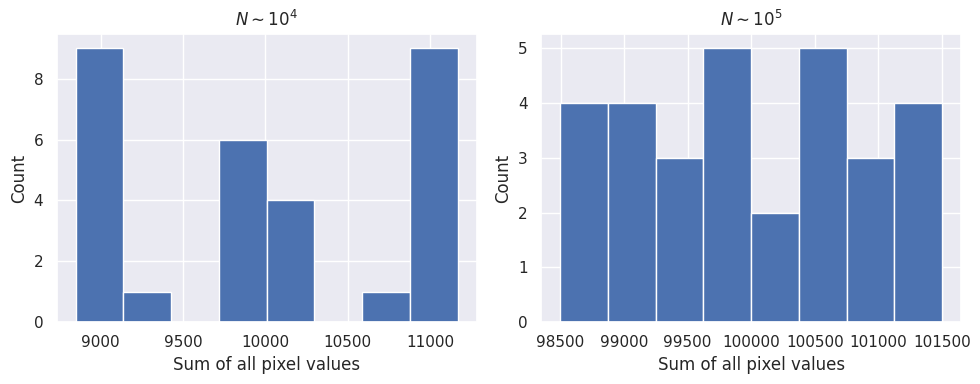

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.io import imread
import re

folder = Path("Number_estimate")
files = sorted(folder.glob("*.tiff"))

pattern = re.compile(r"atom_num=(\d+)")

sum_1e4 = []
sum_1e5 = []

for f in files:
    m = pattern.search(f.name)
    if m is None:
        continue

    atom_num = int(m.group(1))
    img = imread(f)
    total_signal = img.sum()

    if atom_num in [9000,10000,11000]:
        sum_1e4.append(total_signal)
    elif atom_num in [99000, 100000, 101000]:
        sum_1e5.append(total_signal)

sum_1e4 = np.array(sum_1e4)
sum_1e5 = np.array(sum_1e5)

# plot
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].hist(sum_1e4, bins=8)
axes[0].set_title(r"$N\sim10^4$")
axes[0].set_xlabel("Sum of all pixel values")
axes[0].set_ylabel("Count")

axes[1].hist(sum_1e5, bins=8)
axes[1].set_title(r"$N\sim10^5$")
axes[1].set_xlabel("Sum of all pixel values")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The histograms show that the total summed pixel value is strongly correlated with the atom number. The N ~ 10^5 images are shifted to much larger total signals than the N~10^4 images.

### <span style="color:LightGreen">Question 08</span>

Implement a KMeans fit of the 1D atom number data to attempt to recover the true atom number of each image, when comparing images in $N\sim10^4$ and $N\sim10^5$ orders separately.

Are you able to clearly resolve the atom number for each of the subsets above?

1e4 centers: [ 8988.101975    9987.45838044 10986.84623844]
1e5 centers: [ 98835.31634478  99759.87499865 100877.41055585]


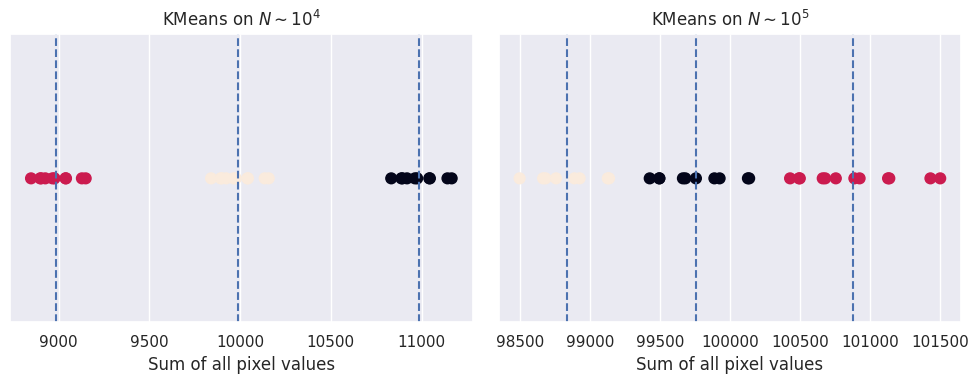

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X_1e4 = sum_1e4.reshape(-1, 1)
X_1e5 = sum_1e5.reshape(-1, 1)

kmeans_1e4 = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans_1e5 = KMeans(n_clusters=3, random_state=0, n_init=10)

labels_1e4 = kmeans_1e4.fit_predict(X_1e4)
labels_1e5 = kmeans_1e5.fit_predict(X_1e5)

centers_1e4 = np.sort(kmeans_1e4.cluster_centers_.flatten())
centers_1e5 = np.sort(kmeans_1e5.cluster_centers_.flatten())

print("1e4 centers:", centers_1e4)
print("1e5 centers:", centers_1e5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(sum_1e4, np.zeros_like(sum_1e4), c=labels_1e4, s=60)
for c in centers_1e4:
    axes[0].axvline(c, linestyle='--')
axes[0].set_title(r"KMeans on $N\sim10^4$")
axes[0].set_xlabel("Sum of all pixel values")
axes[0].set_yticks([])

axes[1].scatter(sum_1e5, np.zeros_like(sum_1e5), c=labels_1e5, s=60)
for c in centers_1e5:
    axes[1].axvline(c, linestyle='--')
axes[1].set_title(r"KMeans on $N\sim10^5$")
axes[1].set_xlabel("Sum of all pixel values")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

I am able to clearly resolve the atom number for each of the subsets above.

### <span style="color:LightGreen">Question 09</span>

Take the images in the **Heavy_tails** dataset. Use singular value decomposition (SVD) to generate a compressed version of each image, by decomposing the data and sampling a rank-$k$ subset of the latent variable space. Reconstruct images for a handful of $k$.

At what point do images with the same $\sigma_{xy}$ but different $\sigma_z$ appear to have the same sized tail in the compressed parameter space?

In [9]:
folder = Path("Heavy_tails")
files = sorted(folder.glob("*.tiff"))

pattern = re.compile(r"sigma=\(([\d.]+)\.\.\.([\d.]+)\.\.\.([\d.]+)\).*seed=(\d+)")

images = []
sigma_xy_list = []
sigma_z_list = []
seed_list = []
names = []

for f in files:
    m = pattern.search(f.name)
    sx = float(m.group(1))
    sy = float(m.group(2))
    sz = float(m.group(3))
    seed = int(m.group(4))

    img = imread(f).astype(float)

    images.append(img)
    sigma_xy_list.append(sx)
    sigma_z_list.append(sz)
    seed_list.append(seed)
    names.append(f.name)

images = np.array(images)
sigma_xy_list = np.array(sigma_xy_list)
sigma_z_list = np.array(sigma_z_list)
seed_list = np.array(seed_list)

n_images, h, w = images.shape
X = images.reshape(n_images, h * w)

print("X shape:", X.shape)
print("unique sigma_xy:", np.unique(sigma_xy_list))
print("unique sigma_z:", np.unique(sigma_z_list))

X shape: (18, 900)
unique sigma_xy: [ 1.   2.5  5.  10.  20. ]
unique sigma_z: [ 1.   2.5  5.  10.  20. ]


In [10]:
U, S, VT = np.linalg.svd(X, full_matrices=False)

In [11]:
def reconstruct_rank_k(X, U, S, VT, k):
    Xk = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
    return Xk.reshape(-1, h, w)

In [12]:
sigma_xy_target = 5.0

seed_target = 0

mask = (sigma_xy_list == sigma_xy_target) & (seed_list == seed_target)
candidate_idx = np.where(mask)[0]

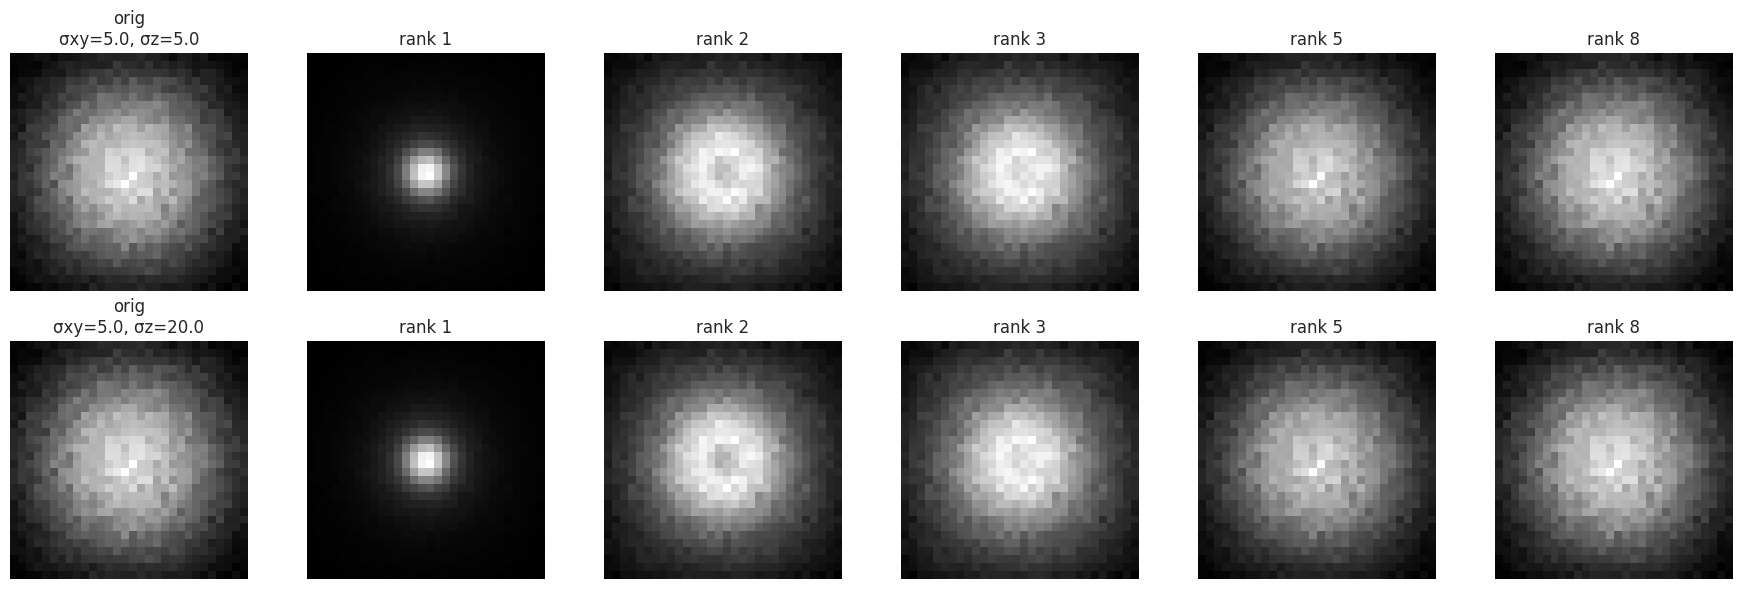

In [13]:
k_list = [1, 2, 3, 5, 8]

Xk_dict = {}
for k in k_list:
    Xk_dict[k] = reconstruct_rank_k(X, U, S, VT, k)

selected_idx = candidate_idx[np.argsort(sigma_z_list[candidate_idx])]

fig, axes = plt.subplots(len(selected_idx), len(k_list) + 1, figsize=(3*(len(k_list)+1), 3*len(selected_idx)))

for row, idx in enumerate(selected_idx):
    # original
    axes[row, 0].imshow(images[idx], cmap="gray")
    axes[row, 0].set_title(f"orig\nσxy={sigma_xy_list[idx]}, σz={sigma_z_list[idx]}")
    axes[row, 0].axis("off")

    # reconstructions
    for col, k in enumerate(k_list, start=1):
        axes[row, col].imshow(Xk_dict[k][idx], cmap="gray")
        axes[row, col].set_title(f"rank {k}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

For this pair of images, the tail difference is largely suppressed at low rank, and by rank 1 the two reconstructions already appear to have essentially the same tail size. Even at rank 2/3 they remain very similar, indicating that the tail information is not strongly preserved in the lowest-rank SVD approximation.

### <span style="color:LightGreen">Question 10</span>

Read through chapter 5 of [5], and implement a similarly structured convolutional neural network (CNN) to extract features from the images in the **Heavy_tails** dataset.

Display a few images from the output of the network? How do they compare to your latent space representations of the data from your SVD?

In [27]:
X = images.copy()

# normalize to [0, 1]
X_min = X.min()
X_max = X.max()
X = (X - X_min) / (X_max - X_min)

# add channel dimension: (N, H, W, 1)
X = X[..., np.newaxis]

print("X shape:", X.shape)

X shape: (18, 30, 30, 1)


In [28]:
crop = 20
start = (X.shape[1] - crop) // 2
end = start + crop

X_use = X[:, start:end, start:end, :]
print(X_use.shape)

(18, 20, 20, 1)


In [33]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

n_images, h, w, c = X_use.shape

inputs = keras.Input(shape=(h, w, 1))

x = layers.Conv2D(8, 5, padding="same", activation="tanh")(inputs)
x = layers.Conv2D(8, 3, padding="same", activation="tanh")(x)

feature_maps = layers.Conv2D(8, 1, padding="same", activation=None, name="feature_maps")(x)

x = layers.Conv2D(16, 3, padding="same", activation="tanh")(feature_maps)
outputs = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
feature_model = keras.Model(inputs, feature_maps)

# implemented a weighted MSE loss
def weighted_mse(y_true, y_pred):
    w = 1.0 + 10.0 * y_true
    return tf.reduce_mean(w * tf.square(y_true - y_pred))

model.compile(optimizer="adam", loss=weighted_mse)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 20, 20, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 20, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 20, 20, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_maps (Conv2D)           │ (None, 20, 20, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 20, 20, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177 (8.50 KB)

 Trainable params: 2,177 (8.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# training
history = model.fit(
    X_use, X_use,
    epochs=200,
    batch_size=4,
    shuffle=True,
    validation_split=0.2,
    verbose=0
)

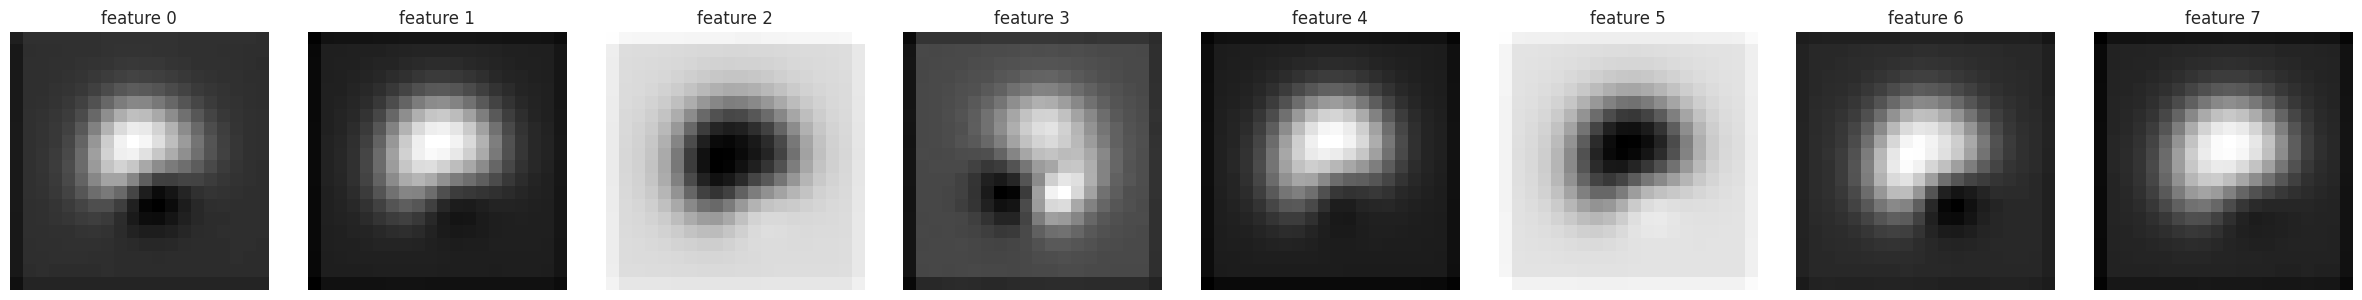

In [38]:
features = feature_model.predict(X_use, verbose=0)

idx = 0

fig, axes = plt.subplots(1, features.shape[-1], figsize=(3*features.shape[-1], 3))

for i in range(features.shape[-1]):
    axes[i].imshow(features[idx, :, :, i], cmap="gray")
    axes[i].set_title(f"feature {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

The displayed CNN outputs are the learned feature maps produced by the network’s feature extraction stage. Unlike the SVD latent representation, which is a linear low-rank description of the whole image, these CNN feature maps are nonlinear and spatially localized. In my SVD results, low-rank reconstructions mainly preserved the overall blob shape and tended to suppress more subtle tail differences, so images with different σ
z could look more similar at small rank. In contrast, the CNN feature maps respond to different local aspects of the cloud morphology, such as the bright central region and the contrast between the center and the surrounding tail/background. Therefore, the CNN representation appears more structured and spatially specific, whereas the SVD latent space is more global and linear.

## <span style="color:Orange">References</span>

* [__<span style="color:Red">1</span>__] S. S. Kondov, W. R. McGehee, J. J. Zirbel, and B. DeMarco, Science 334, 66 (2011).

* [__<span style="color:Red">2</span>__] W. B. Cairncross, D. N. Gresh, M. Grau, K. C. Cossel, T. S. Roussy, Y. Ni, Y. Zhou, J. Ye, and E. A. Cornell, Physical Review Letters 119, (2017).

* [__<span style="color:Red">3</span>__] Goodman, J. W. (2005). Introduction to Fourier optics. 3rd ed.

* [__<span style="color:Red">4</span>__] Foot, C. (2005). Atomic physics. Oxford University Press, USA.

* [__<span style="color:Red">5</span>__] C. J. Schuler, Machine learning approaches to image deconvolution. Eberhard Karls University of Tübingen (2014).

## <span style="color:Orange">Acknowledgements</span>

* Initial version: Max Gold with some guidance from Mark Neubauer

© Copyright 2026